## Review of data analysis techniques for turbulence data from both, numerical simulations and experimental measurements.

### Author: Marc Calaf
### Date: 25/07/2022



In [1]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt

parameters = {'axes.labelsize': 16,'xtick.labelsize': 14,'ytick.labelsize': 14,'axes.titlesize':16}
plt.rcParams.update(parameters)

# Include the path to where you have locally stored the data file.
file_path = "/Users/mcalaf/Documents/Utah/Courses/Summer_school_Norway_2022/Lecture1/"

os.chdir(file_path)

# Next, we load the information in the data file onto the variable Data. This variable is a dataarray, 
# with 2 dimensions (.dims) and 4 coordinates (.coords, u,v,w,T)

Data = xr.open_dataarray("SonicData.nc")

# To simplify the analysis, we will focus for now only on the streamwise velocity, u, 
# and only using one hour of data
    
u = Data.data[:,0]

Npoints = np.size(u)

In [2]:
def Plot_IPAQS():

    #This function loads and plots a sample experimental dataset from the IPAQS field experiment.
    # We begin by importing the Libraries that we will need for the analysis in Python


    

    t0 = 0
    tf = Npoints*(1/20)/3600

    plt.figure(figsize=(15,5))
    plt.plot(np.arange(0,Npoints)*(1/20)/3600,u)

    plt.xlabel('t [h]')
    plt.ylabel('u(t) [m/s]')
    plt.xlim((t0,tf))

    plt.tight_layout()
    plt.show()


## Motivation

Let's consider a velocity field from the atmsopheric boundary layer (ABL)

As an example, below I include data obtained with Sonic Anemometers during the **I**dealized **P**lanar **A**rray study for **Q**uantifying **S**patial heterogeneity (IPAQS): 

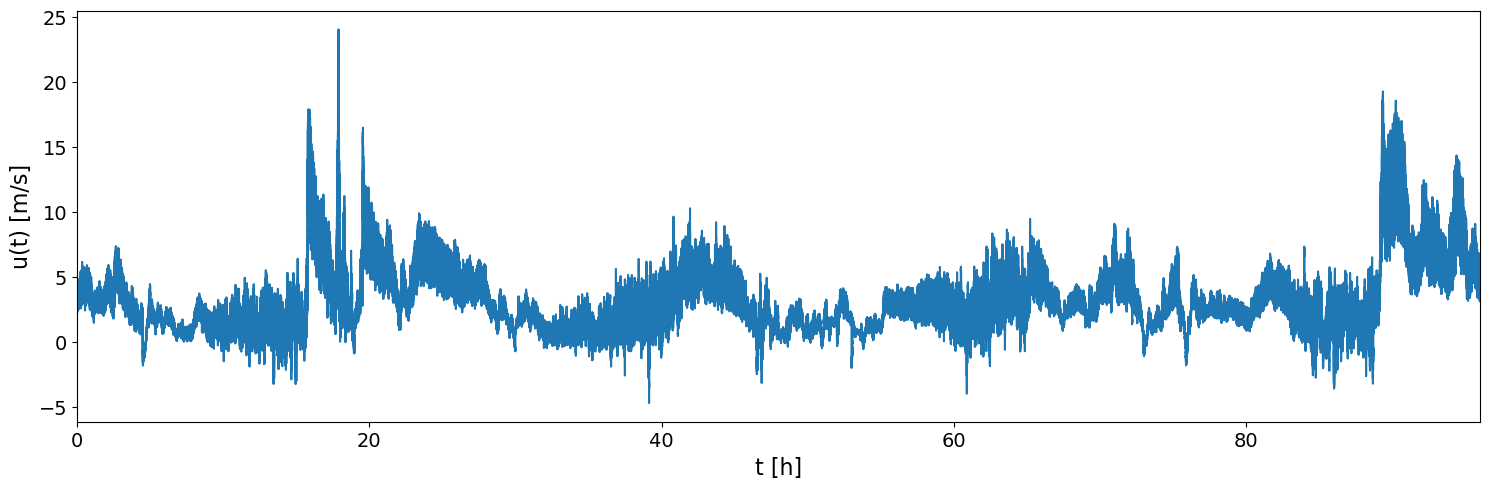

In [3]:

Plot_IPAQS()


In [6]:
def Plot_IPAQS2():


    fig, axs=plt.subplots(1,1,figsize=(15,5))

    t0 = 0
    tf = Npoints*(1/20)/3600

    t1_0 = int(24*3600*20)
    t1_f = int(t1_0 + (4*3600*20))

    t2_0 = int(50*3600*20)
    t2_f = int(t2_0 + (4*3600*20))

    axs.plot(np.arange(0,Npoints)/20/3600,u)
    axs.plot(np.arange(t1_0,t1_f)/20/3600,u[t1_0:t1_f],color='orange')
    axs.plot(np.arange(t2_0,t2_f)/20/3600,u[t2_0:t2_f],color='red')
    axs.axvline((t1_0/20/3600), -5, 25, color='k',linestyle='-.')
    axs.axvline((t1_f/20/3600), -5, 25, color='k',linestyle='-.')
    axs.axvline((t2_0/20/3600), -5, 25, color='k',linestyle='-.')
    axs.axvline((t2_f/20/3600), -5, 25, color='k',linestyle='-.')

    #N = 3600*20
    #avg_u = np.convolve(u, np.ones(N)/N, mode='valid')

    #axs.plot((np.arange(0,np.size(avg_u))+1800*20)/20/3600,avg_u,'-k')

    axs.set_xlabel('t [h]')
    axs.set_ylabel('u(t) [m/s]')
    axs.set_xlim((t0,tf))

    plt.tight_layout()
    plt.show()



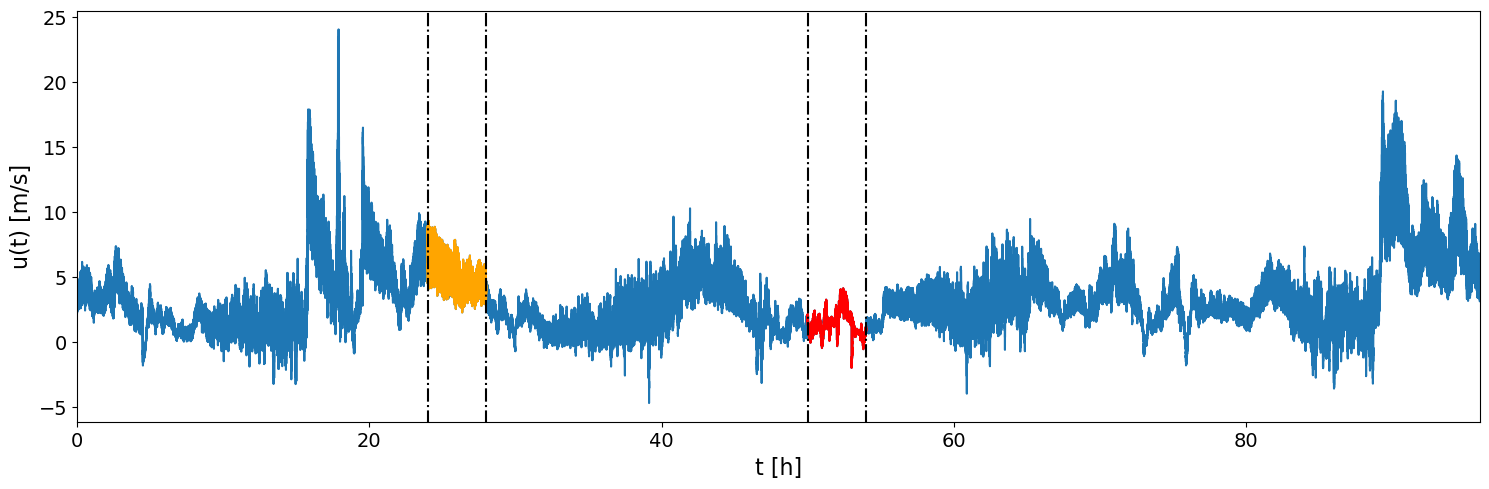

In [8]:
Plot_IPAQS2()

In [9]:
def Plot_IPAQS3():
    
    fig, axs=plt.subplots(1,1,figsize=(15,5))

    t0 = 0
    tf = Npoints*(1/20)/3600

    t1_0 = int(24*3600*20)
    t1_f = int(t1_0 + (4*3600*20))

    t2_0 = int(50*3600*20)
    t2_f = int(t2_0 + (4*3600*20))

    axs.plot(np.arange(0,Npoints)/20/3600,u)
    axs.plot(np.arange(t1_0,t1_f)/20/3600,u[t1_0:t1_f],color='orange')
    axs.plot(np.arange(t2_0,t2_f)/20/3600,u[t2_0:t2_f],color='red')
    axs.axvline((t1_0/20/3600), -5, 25, color='k',linestyle='-.')
    axs.axvline((t1_f/20/3600), -5, 25, color='k',linestyle='-.')
    axs.axvline((t2_0/20/3600), -5, 25, color='k',linestyle='-.')
    axs.axvline((t2_f/20/3600), -5, 25, color='k',linestyle='-.')

    N = 3600*20
    avg_u = np.convolve(u, np.ones(N)/N, mode='valid')

    axs.plot((np.arange(0,np.size(avg_u))+1800*20)/20/3600,avg_u,'-k')

    axs.set_xlabel('t [h]')
    axs.set_ylabel('u(t) [m/s]')
    axs.set_xlim((t0,tf))

    plt.tight_layout()
    plt.show()

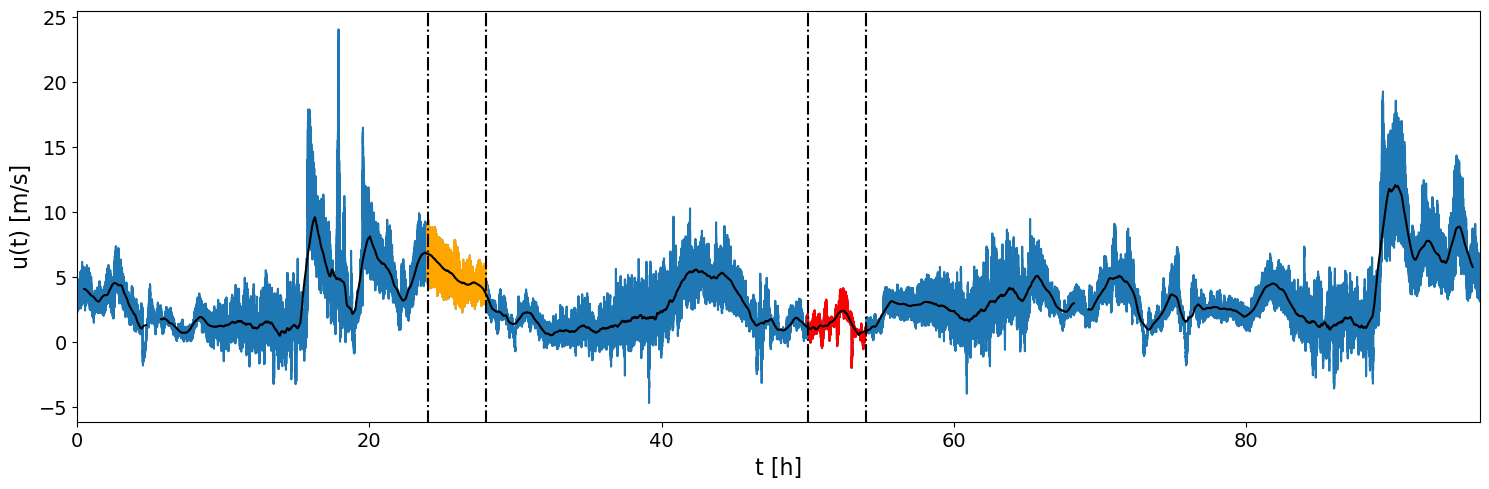

In [10]:
Plot_IPAQS3()

## Statistical analysis of data,...


### Fluctuations about the mean

* Figure 1 illustrates portions of two random functions of time which have identical means.


* They are members of different ensembles since the amplitudes of their fluctuations are not distributed the same. 

![](figure1.png)
**Figure 1** - *A typical random function of time with non-zero mean value.*


<div class="alert alert-block alert-danger">
    It is therefore clear that the <b>mean</b> will not suffice as statistical measure alone.
</div>


* Statistical properties of the fluctuations about the mean (or simply the fluctuations) defined by:

\begin{equation}
x' = x - X \label{eq4}
\end{equation}

It is easy to see that the average of the fluctuation is zero, i.e.

\begin{equation}
\langle x' \rangle = 0 \label{eq5}
\end{equation}

The **variance** is defined as:

\begin{equation}
var[x] \equiv \langle (x')^2 \rangle = \langle [x - X]^2 \rangle = \text{lim}_{N\to\infty}\frac{1}{N}\sum_{n=1}^N [x_n - X]^2 \label{eq6}
\end{equation}

* The variance can also be referred to as the **second central moment of $x$**. The word central implies that the mean has been subtracted off before squaring and averaging. 


* If two random variables are identically distributed, then they must have the same mean and variance.


* The variance is closely related to another statistical quantity called the **standard deviation** or **root mean square (rms)** value of the random variable $x$, which is denoted by the symbol, $\sigma_x$. Thus,

\begin{equation}
\sigma_x \equiv (var[x])^{1/2} \label{eq8}
\end{equation}


<div class="alert alert-block alert-danger">
    But again, sometimes <b>second order statistics</b> alone do not suffice either.
</div>


### Higher moments

For example, Figure 2 illustrates two random variables of time that have the same mean and also the same variances, but clearly they are still quite different. 

![](figure2.png)
**Figure 2** - *Two random functions of time having the same mean and variance, but very different higher moments.*


The *m*-th moment of the random variable is defined as:

\begin{equation}
\langle x^m \rangle = \text{lim}_{N\to\infty} \sum_{n=1}^{N} x^m_n \label{eq9} 
\end{equation}

It is usually more convenient to work with the *central moments* defined by:

\begin{equation}
\langle x^m \rangle = \langle (x -X)^m \rangle =  \text{lim}_{N\to\infty} \sum_{n=1}^{N} [x_n - X]^m \label{eq10} 
\end{equation}

The central moments give direct information on the distribution of the values of the random variable about the mean. It is easy to see that the variance is the second central moment (i.e., $m=2$). 



Of special relevance are:

* **Skewness** (Normalized 3rd order moment): provides a measure of the symmetry of the distribution.

\begin{equation}
S = \frac{\langle(x -X)^3\rangle}{\langle (x -X)^2\rangle^{2/3}}
\end{equation}

* **Kurtosis** (Normalized 4th order moment): provides a measure of the weight of the tails.

\begin{equation}
K = \frac{\langle (x -X)^2\rangle}{\langle (x -X)^2\rangle^{2}}
\end{equation}


(For a Gaussian pdf, the skewness is zero and the kurtosis is equal to three.)


![](figure4.png)
**Figure 3** - *Distributions that have the same mean and standard deviation, but are clearly quite different. Beneath them are shown random functions of time which might have generated them. (a) & (b) have zero skewness, with (a) having larger Kurtosis (larger tails) than (b). Distributions (c) and (d), on the other hand, have non-zero values for the odd moments, because of their asymmetry.*



<div class="alert alert-block alert-warning">
<b>Practice:</b> Use the IPAQS dataset (or other dataset of your interest) and compute the corresponding PDF, and compute the 1st, 2nd, 3rd, and 4th order moments. Truncate your dataset in 4 different periods, and do the same analysis on this shorter periods. Do the statistical characteristics of the signal change with time?
</div>

## Some methods to determine the characteristic 'scales' of a turbulent signal:

>
> * Fourier Decomposition
> * Wavelet Analysis
> * Multi-resolution Decomposition
> * Proper Orthogonal Decomposition

## Fourier Decomposition



Fourier analysis tells us that any *well-behaved* continuous function, $f(t)$ (where $t$ is time, although it could also be space, $x$, or both) can be described by an infinite Fourier series - namely, the sum of an infinite number of sine and cosine terms. 

\begin{equation}
f(t) = \int_{k=0}^{\infty} F(k) \,e^{i (\frac{2\pi k}{N})t} dk =  \int_{k=0}^{\infty} F(k) \Big[cos\Big(\frac{2\pi k}{N}t\Big) + i sin\Big( \frac{2\pi k}{N}t\Big)\Big] dk
\end{equation}

In the case of a discrete time series with a finite number of points, we are required to have only a finite number of sine and cosine terms to fit our data points exactly,

\begin{equation}
f(t) = \sum_{k=0}^N F(k)\, e^{i 2\pi kt/N} =  \sum_{k=0}^N F(k) \Big[cos\Big(\frac{2\pi k}{N}t\Big) + i sin\Big( \frac{2\pi k}{N}t\Big)\Big]
\end{equation}



In practice this means that if we take let's say a discrete time signal of velocity $u(t)$, then it should be possible to decompose this signal as the sum of a discrete subset of waves, where $F(k)$ are the Fourier coefficients.

<div class="alert alert-block alert-info">
<b>Example:</b> To illustrate the Fourier decomposition of a random signal, we will use a certain velocity field obtained during the IPAQS field campaign.
</div>

In [5]:
def Plot_IPAQS4():

    # We begin by importing the Libraries that we will need for the analysis in Python

    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import xarray as xr

    # Include the path to where you have locally stored the data file.
    file_path = "/Users/mcalaf/Documents/Utah/Courses/Summer_school_Norway_2022/Lecture1/"

    os.chdir(file_path)

    # Next, we load the information in the data file onto the variable Data. This variable is a dataarray, 
    # with 2 dimensions (.dims) and 4 coordinates (.coords, u,v,w,T)

    Data = xr.open_dataarray("SonicData.nc")

    # To simplify the analysis, we will focus for now only on the streamwise velocity, u, 
    # and only using one hour of data
    t0 = 0
    tf = 1*3600*20 #Number of points in one hour at 20Hz measurement frequency.
    u = Data.data[t0:tf,0]

    # At the same time, and for the sake of simplifying the analysis, we Rensure there are no NaNs in the Signal.
    # If we encounter any, we set them to zero. Note, that when you analyze your data you might/could decide using 
    # more advnaced methods to fill in the gaps. Clearly, depending on what you do, it might affect the outcome
    # of your analysis.

    testNan = np.isnan(u)
    ind = np.where(testNan == True)
    u[ind] = 0

    Number_of_Nans = np.size(ind) #Determines how many NaNs have been found.
    # Next, we define a couple parameters related to the signal.print(f"The total number of NaNs found is of {Number_of_Nans} points")

    Npoints = np.size(u) #Total number of points in the ensemble time series.

    #print(f"Number of points in the signal= {Npoints}")
    #print(f"Number of NaNs in the signal= {Number_of_Nans}")

    #parameters = {'axes.labelsize': 16,'xtick.labelsize': 14,'ytick.labelsize': 14,'axes.titlesize':16}
    #plt.rcParams.update(parameters)

    plt.figure(figsize=(15,5))
    plt.plot(np.arange(0,Npoints)*(1/20),u)

    plt.xlabel('t [s]')
    plt.ylabel('u(t) [m/s]')
    plt.xlim((0,3600))

    plt.tight_layout()
    plt.show()


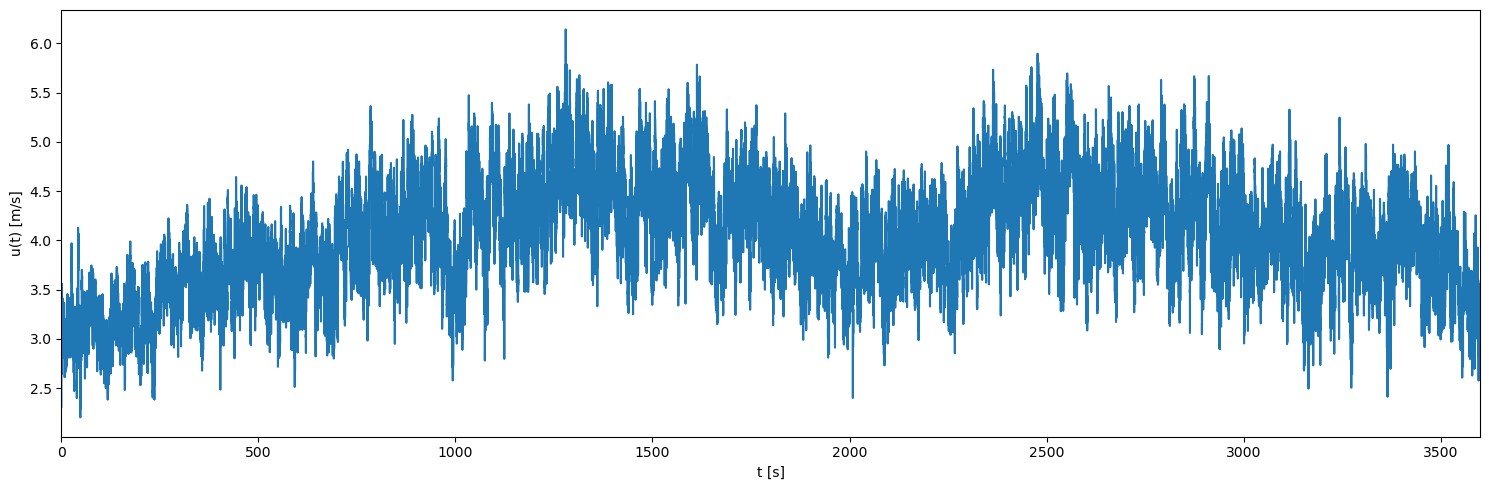

In [6]:
# IPAQS streamwise velocity obtained from Sonic Anemometer  

Plot_IPAQS4()

In [14]:
# At this point, we have set ourselves with a function (streamwise velocity, u(t)) and we would like 
# to decompose it as a function of Fourier modes (i.e. sin and cos functions).

xdft = np.fft.fft(u,Npoints,norm='forward') #Compute the FFT of the piece of signal we are interested in.

Freq = 20 #Hz
dt = 1/Freq #s
time = np.arange(0,dt*Npoints,dt)
T = Npoints*dt
fres = 1/T  #[This is the lowest frequency]. After folding the fftw we only have N/2+1 points.
f = np.arange(0,Npoints)*fres  # This creates the frequency vector of length N. 
                               # The 0 frequency would be the corresponding one for the mean.

    
#mode_1 = xdft[1]*np.cos((2*np.pi*f[1])*time)

nmodes = 100
Recons_signal = np.zeros((nmodes,Npoints))
cos_modes = np.zeros((nmodes,Npoints))
sin_modes = np.zeros((nmodes,Npoints))

Recons_signal[0,:] = (np.real(xdft[0])*np.cos((2*np.pi*f[0])*time) - np.imag(xdft[0])*np.sin((2*np.pi*f[0])*time))    
for i in range(1,nmodes):
    cos_modes[i,:] = np.cos((2*np.pi*f[i])*time)
    sin_modes[i,:] = np.sin((2*np.pi*f[i])*time)
    Recons_signal[i,:] = Recons_signal[i-1,:] + (np.real(xdft[i])*np.cos((2*np.pi*f[i])*time) - np.imag(xdft[i])*np.sin((2*np.pi*f[i])*time))    

signal = np.zeros((Npoints,))
for i in range(0,int(Npoints)):
    signal = signal + (np.real(xdft[i])*np.cos((2*np.pi*f[i])*time) - np.imag(xdft[i])*np.sin((2*np.pi*f[i])*time))





In [15]:
#Function that defines the Graphical Representation of the Analysis:

def GraphRepresentation(u):

    fig, axs=plt.subplots(5,2,figsize=(15,10))
    axs[0,0].plot(time,cos_modes[1,:])
    axs[0,0].plot(time,sin_modes[1,:])
    axs[0,1].plot(time,u)
    axs[0,1].plot(time,Recons_signal[1,:])

    axs[1,0].plot(time,cos_modes[2,:])
    axs[1,0].plot(time,sin_modes[2,:])
    axs[1,1].plot(time,u)
    axs[1,1].plot(time,Recons_signal[2,:])

    axs[2,0].plot(time,cos_modes[3,:])
    axs[2,0].plot(time,sin_modes[3,:])
    axs[2,1].plot(time,u)
    axs[2,1].plot(time,Recons_signal[3,:])

    axs[3,0].plot(time,cos_modes[nmodes-1,:])
    axs[3,0].plot(time,sin_modes[nmodes-1,:])
    axs[3,1].plot(time,u)
    axs[3,1].plot(time,Recons_signal[nmodes-1,:])

    axs[4,0].plot(time,u)
    axs[4,1].plot(time,signal,color='orange')

    axs[0,0].autoscale(enable=True, axis='x', tight=True)
    axs[1,0].autoscale(enable=True, axis='x', tight=True)
    axs[2,0].autoscale(enable=True, axis='x', tight=True)
    axs[3,0].autoscale(enable=True, axis='x', tight=True)
    axs[4,0].autoscale(enable=True, axis='x', tight=True)
    axs[0,1].autoscale(enable=True, axis='x', tight=True)
    axs[1,1].autoscale(enable=True, axis='x', tight=True)
    axs[2,1].autoscale(enable=True, axis='x', tight=True)
    axs[3,1].autoscale(enable=True, axis='x', tight=True)
    axs[4,1].autoscale(enable=True, axis='x', tight=True)

    axs[4,0].set_xlabel('time [s]')
    axs[4,1].set_xlabel('time [s]')
    axs[0,0].set_ylabel('Modes 1');axs[0,1].set_ylabel('R1')
    axs[1,0].set_ylabel('Modes 2');axs[1,1].set_ylabel('R1+R2')
    axs[2,0].set_ylabel('Modes 3');axs[2,1].set_ylabel('R1+...+R3')
    axs[3,0].set_ylabel('Modes 100');axs[3,1].set_ylabel('R1+...+R100')
    axs[4,0].set_ylabel('O. Signal');axs[4,1].set_ylabel('R1+...+RN')
    axs[0,0].set_title('Fourier Modes');axs[0,1].set_title('Reconstructed Signal')


    plt.tight_layout()
    plt.show()



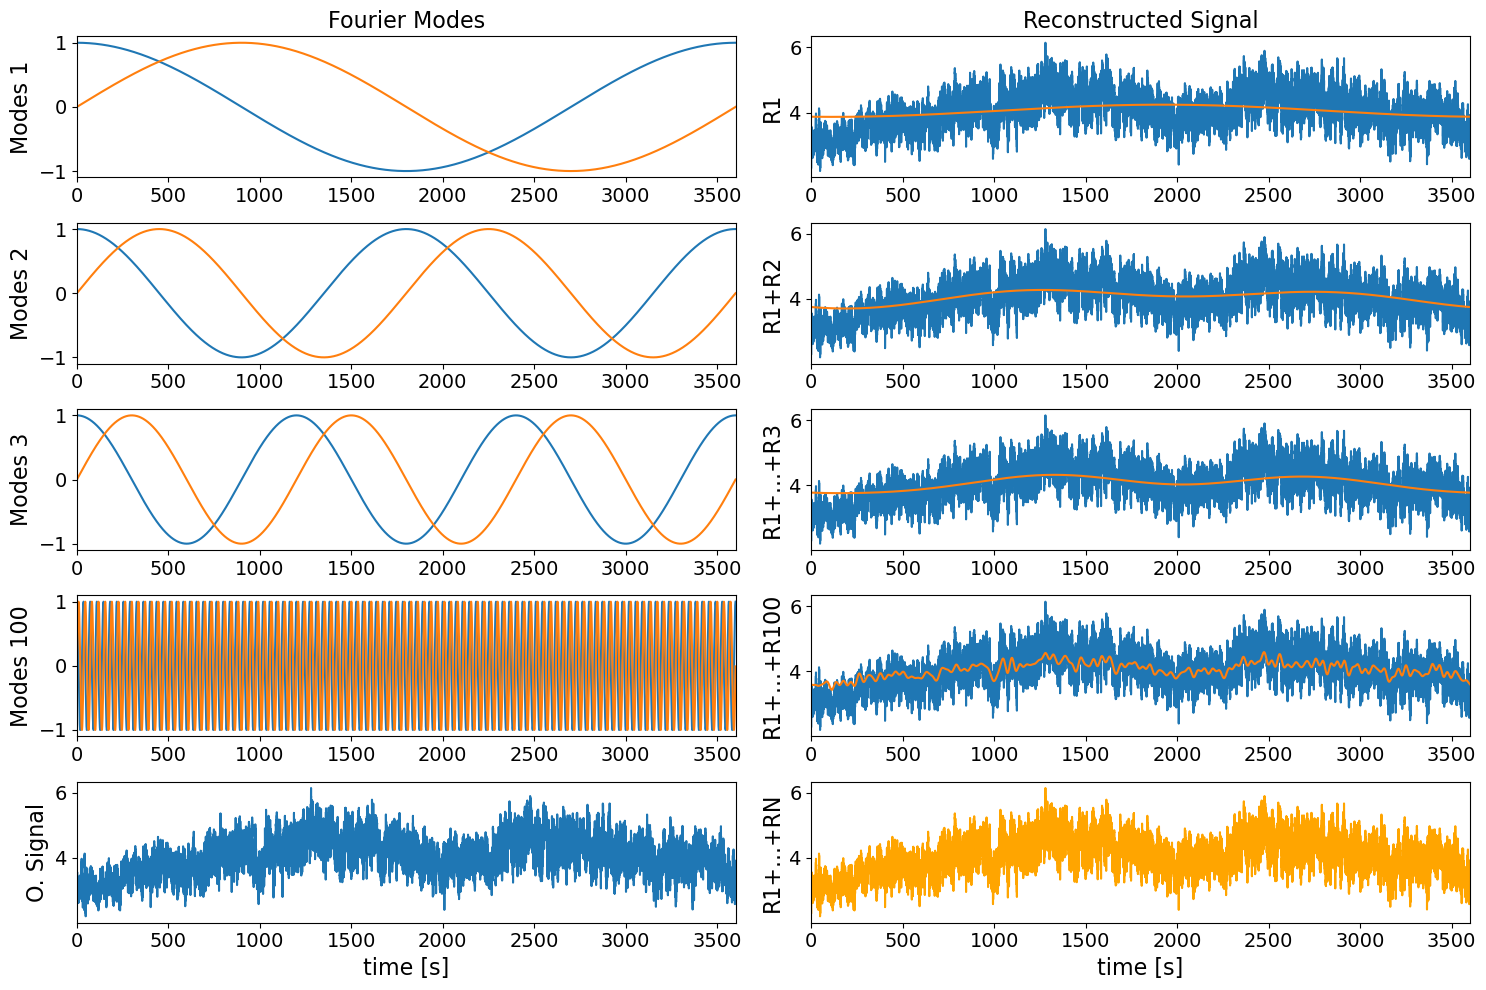

In [16]:
#Graphical Representation of the results:

GraphRepresentation(u)

<div class="alert alert-block alert-info">
$\Longrightarrow$ <b>Note:</b> Now that we have been able to decompose the signal based on contributions of $\mathbf{sin}$ and $\mathbf{cos}$ functions at different frequencies, one can do many things,...
</div>

### a. Compute scalewise turbulent flux:

Let's say one is interested in computing the sensible heat flux at a given meteorological station. Traditionally what one would do is the following:

1. Decide averaging time (e.g. let's pick 60 min, same as the dataset length)
2. Compute fluctuations:
    * $u'(t) = u(t)-\overline{u(t)}$
    * $T'(t) = T(t)-\overline{T(t)}$
3. Multiply and average: $\overline{u'T'}$.

This provides the turbulent flux as a result of the effect of all turbulent eddies/oscillations.

If instead we now use the Fourier decomposition described above, we can compute fluxes as a function of frequency contribution,...

\begin{equation}
\overline{u'T'} = \frac{1}{N}\sum_{t=1}^N u'(t)T'(t) = \frac{1}{N}\sum_{n=1}^N \Big[\underbrace{\Big(\sum_{k=1}^N A(k)\, e^{i \frac{2\pi k}{N}t}\Big)}_{u'(t)}\underbrace{\Big(\sum_{l=1}^N B(l)\, e^{i \frac{2\pi l}{N} t}\Big)}_{T'(t)} \Big]
\end{equation}


<div class="alert alert-block alert-danger">
<b>Problem:</b> In this approach, when computing the product of the <b>sums</b> one has to also take into consideration the cross terms, which makes the corresponding scalewise interpretation a bit fuzzy. 

$\Longrightarrow$ We will see later that there is another way around in the spectral space!
</div>

### Discrete energy spectrum

The square of the norm of the complex Fourier transform of a signal $U$ for any frequency $k$ can be written as

\begin{equation}
|F_U(k)|^2 = |F_{\text{real part}}(k)|^2 + |F_{\text{imaginary part}}(k)|^2
\end{equation}

When summed over frequencies $k=1$ to $N-1$, the result equals the total variance of the original time series:

\begin{equation}
\sigma_U^2 = \frac{1}{N}\sum_{i=0}^{N-1} (U_i-\overline{U})^2 = \sum_{k=1}^{N-1}|F_U(k)|^2
\end{equation}

* One can interpret $|F_U(k)|^2$ as the portion of variance explained by waves of frequency $k$. 


* $k=0$ is the frequency of the mean value and does not contribute to the variance.


* The variance of velocity fluctuations, $u'$, has the same units as turbulence kinetic energy per unit mass. Thus, the spectrum of velocity is called the discrete energy spectrum. 


* The **discrete spectral energy**, $E_A(n)$, is defined as $E_A(n)= 2\,|F_A(n)|^2$
    * This is for $n=1$ to $n_f$, with $N= odd$. 
    * For $N=even$, $E_A(n)= 2\,|F_A(n)|^2$ is used for frequencies from $n=1$ to $(n_f -1)$, along with $E_A(n)=|F_A(n)|^2$ (not times 2) at the Nyquist frequency. 








<div class="alert alert-block alert-info">
<b>Example:</b> How to compute the Energy spectrum in practice? and how do we interpret it?
</div>

### Steps to Compute the Energy Spectra

1. Take the signal you are interested to analyze (e.g. $u(t)$)


2. Remove NaNs from the signal (e.g. add zeros, interpolate, etc).


3. Transform your signal to a new signal with length power of 2 (e.g. $2^M$).


4. Remove the "mean" of the signal you will Fourier transform. (Challenge: What is the right mean period?)


5. Window the Signal to enforce periodicity! -- (Sin/Cos functions are periodic)


6. Compute Fourier coefficients ($F_U(k)$).



7. Compute Energy Spectra, $E(k) = 2|F_U(k)|^2$


8. Compute the frequency vector (f)


9. Check that by summing the Energy Spectra you recover the Variance of the Window-filtered signal.


10. Plot


In [17]:

def FourierEnergySpectra():
    
    #Here we load once again the data to be analyzed, and then we compute the Energy Spectra. 

    # Next we import again the Libraries that we will need to 
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import xarray as xr

    # Include the path to where you have locally stored the data file.
    file_path = "/Users/mcalaf/Documents/Utah/Courses/Summer_school_Norway_2022/"

    os.chdir(file_path)

    #----------------------------------------------------------------------------------
    #----------------------------------------------------------------------------------

    # Next, we load the information in the data file onto the variable Data. This variable is a dataarray, 
    # with 2 dimensions (.dims) and 4 coordinates (.coords, u,v,w,T)

    Data = xr.open_dataarray("SonicData.nc")

    # To simplify the analysis, we will focus for now only on the streamwise velocity, u.
    u = Data.data[:,0]

    #This function reads in a velocity vector.

    # At the same time, and for the sake of simplifying the analysis, we Rensure there are no NaNs in the Signal.
    # If we encounter any, we set them to zero. Note, that when you analyze your data you might/could decide using 
    # more advnaced methods to fill in the gaps. Clearly, depending on what you do, it might affect the outcome
    # of your analysis.

    testNan = np.isnan(u)
    ind = np.where(testNan == True)
    u[ind] = 0

    Number_of_Nans = np.size(ind) #Determines how many NaNs have been found.
    # Next, we define a couple parameters related to the signal.print(f"The total number of NaNs found is of {Number_of_Nans} points")

    #Make the Signal a power of 2.
    M = np.floor(np.log2(len(u))) #Maximum Power of 2 within the length of the signal measure at 20Hz.
    u_short = u[0:int(2**M)]

    #----------------------------------------------------------------------------------
    #----------------------------------------------------------------------------------

    # Next, we define a couple parameters related to the signal.

    Nperiod = 3600 #Lenth in seconds of the period of study.
    Freq = 20 #frequency of measurements in Hz.

    Npoints = Nperiod*Freq #This is the total number of points in one period (window).
                    #Here we take a period of 1h.



    shift = Npoints #e.g. int(Nperiod/80)#int(Nperiod/2) #Nperiod      #Number of points we shift.
    #Try playing with the outcome of changing the sift value. 

    Ntotal = np.size(u_short) #Total number of points in the ensemble time series.
    Nsnap = np.int64((np.floor((Ntotal-Npoints)/shift)) + 1) #Number of Snapshots generated based on the length of 
                                                         #the time series & the selected shift.
    
    #----------------------------------------------------------------------------------
    #----------------------------------------------------------------------------------

    # At this time, we are ready to compute the energy spectrum for different snapshots of the signal.

    from scipy import signal

    dt = 1/Freq #s
    T = Npoints*dt

    fres = 1/T  #[This is the lowest frequency]. After folding the fftw we only have N/2+1 points.
 
    f = np.arange(0,int(Npoints/2))*fres  # This creates the frequency vector of length N/2+1. 
                                       # The 0 frequency would be the corresponding one for the mean.

    parameters = {'axes.labelsize': 12,'xtick.labelsize': 10,'ytick.labelsize': 10,'axes.titlesize':12}
    plt.rcParams.update(parameters)
    
    for nWind in range(0,Nsnap):    
    #for nWind in range(0,1):    
    
        x0 = nWind*shift #First point of the Snapshot
        xf = Npoints + (nWind*shift) #Last point of the snapshot

        N = Npoints #Number of points in each snapshot

        Signal = u_short[x0:xf] - np.mean(u_short[x0:xf])
        Window = signal.windows.hann(Npoints)
        WSignal = Signal*Window
        #WSignal = Signal*1
    
        if (nWind == 0):
            plt.figure()
            plt.plot(np.arange(0,Npoints)*dt,Signal)
            plt.plot(np.arange(0,Npoints)*dt,WSignal)
            plt.xlabel('t[s]')
            plt.ylabel('u(t)')
            plt.show()
    
        #----------------------------------------------------------
        #Computing the Fourier Transform and the Power Spectral Density:
    
        xdft = np.fft.fft(WSignal,N,norm='forward') #Compute the FFT of the piece of signal we are interested in.
        xdft1 = xdft[0:int(N/2)+1] #For an even signal, we keep the trasnformed terms from n =0 to n=N/2 
    
    
        psdx = np.abs(xdft1*np.conj(xdft1)) #Compute the power spectra.
        #psdx = np.square(np.abs(xdft1))    #This is an equivalent way to compute the power spectra.
    
        psdx[1:int(N/2)] = 2* psdx[1:int(N/2)] #Multiply by a factor 2, because of the folding. 
                                           #Because this is an even signal, the last element (psdx[int(N/2)])
                                           #is not multiplied by two.

        #----------------------------------------------------------

        if (nWind == 0):
            PDens = np.empty((Nsnap,len(psdx)),dtype='float',order = 'F')

        PDens[nWind,:] = psdx #We compile the energy spectrum for each period of time in a new vector, so we can
                          #do some averaging afterwards.


        # Comparing the Variance with the sum of the Spectra Power:
        if (nWind == 0):
            var = np.var(WSignal)
            var_FFT = np.sum(psdx[1:int(N/2)]) #Note that we don't sum the contribution of the first element
                                               #since this corresponds to the mean!
            print(f'The statistical variance of the signal is {var}')
            print(f'The variance computed as the sum of the power spectra is {var_FFT}')

        
    #%whos

    #----------------------------------------------------------------------------------
    #----------------------------------------------------------------------------------

    # Graphical Representation of the results:

    avgPDens =np.mean(PDens,axis=0)

    fig, axs=plt.subplots(1,2,figsize=(10,5))

    axs[0].loglog(f,PDens[0,0:1800*20],'-')
    axs[0].loglog(f,avgPDens[0:1800*20],'-r')
    axs[0].set_xlabel('$f [Hz]$')
    axs[0].set_ylabel('$E(f)$')

    axs[1].loglog(f,f*PDens[0,0:1800*20],'-')
    axs[1].loglog(f,f*avgPDens[0:1800*20],'-r')
    axs[1].set_xlabel('$f [Hz]$')
    axs[1].set_ylabel('$f*E(f)$')

    plt.tight_layout()
    plt.show()
    
    


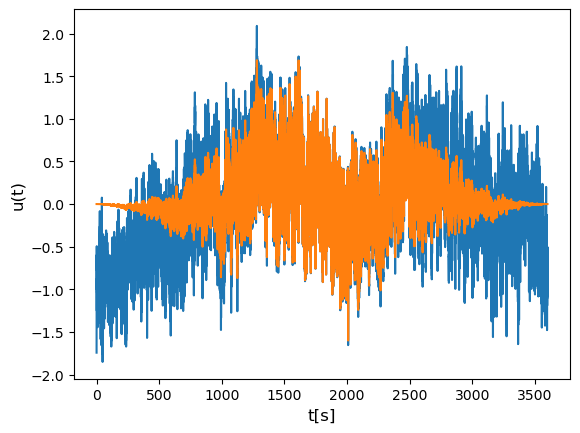

The statistical variance of the signal is 0.0988988722912316
The variance computed as the sum of the power spectra is 0.09889875560946601


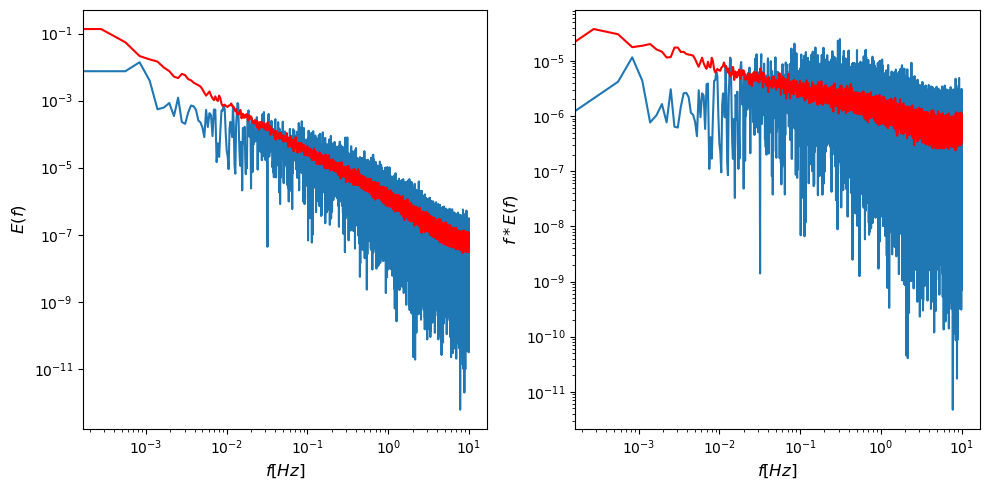

In [18]:

#Compute the energy spectra
FourierEnergySpectra()

## Spectra of Two Variables (Cospectrum)

* Just as we can find the spectrum for a single variable, we can also find a spectrum for a product of two variables. 


* For example, given observations of $w'(t)$ and $u'(t)$, one can create a new time series $u'w'(t)$ on which one can perform routine spectral analyses using an FFT. 


* Occasionally it is useful to get more information about the spectrum of $u'w'(t)$, such as how the phase of the $w'$ fluctuations relate to the phase of the $u'$ fluctuations as a function of frequency. 


* Cross-spectrum analysis relates the spectra of two variables.

### Phase and phase shift:

Phase refers to the position within one wave, such as at the crest or the trough. It is often given as an angle. For example,the crest of a sine wave occurs at $90^{\circ}$, or at $\pi/2$ radians. Phase shift refers to the angle between one part of a wave like the crest and some reference point like a "start time" or the crest of another wave. 

The equation for a single sine wave of amplitude $C$ that is shifted by angle $\phi$ to the right is:

\begin{equation}
A(k,n) = C(n)\,sin\Big(\frac{2\pi k n}{N} - \phi(n)\Big)
\end{equation}

Through trigonometric identities, one can show that the same wave described above can also be written as the sum of one sine wave and one cosine wave:

\begin{equation}
A(k,n) = C_s(n)\,sin\Big(\frac{2\pi k n}{N}\Big) + C_c(n)\,cos\Big(\frac{2\pi k n}{N}\Big)
\end{equation}

where $C_s = C\,cos\phi$ and $C_c = C\,sin\phi$. As discussed earlier the Fourier transforms give the amplitudes of sine and cosine terms in the spectral decomposition of the original field. Thus, one can also interpret the spectra in terms of an amplitude and phase shift for waves of each frequency.


### Cross Spectra

* Define $G_A = |F_A(n)|^2$ as the unfolded spectral energy for variable A and frequency n. 


* We can rewrite this definition as $G_A = F_A^*\,F_A$, where $F_A^*$ is the complex conjugate of $F_A$ and where the dependence on $n$ is still implied. 


* Demonstration of this last definition:
    
    * Let $F_A = F_{A_r} + i\,F_{A_i}$ where subscripts $r$ and $i$ denote real and imaginary parts respectively. 
    
    * Thus, the complex conjugate is simply $F_A = F_{A_r} - i\,F_{A_i}$. 
    
    * As a result, the expression for the spectral energy can now be written as:

        \begin{align}
        G_A &= F_A^*\,F_A \nonumber\\
        & = (F_{A_r} + i\,F_{A_i})(F_{A_r} - i\,F_{A_i}) \nonumber \\
        & = F_{A_r}^2 + iF_{A_i}F_{A_r} - iF_{A_i}F_{A_r} - i^2F_{A_i}^2 \nonumber\\
        & = F_{A_r}^2 + F_{A_i}^2 \nonumber\\
        & = |F_A(n)|^2
        \end{align}

        leaving the magnitude square as a real number. 
 

### Cross Spectra 

* Similarly, one can now define the cross spectrum between A and B by 

\begin{equation}
G_{AB} = F_A^*\,F_B = F_{A_r}F_{B_r} + iF_{A_r}F_{B_i} - iF_{A_i}F_{B_r} - i^2 F_{A_i}F_{B_i}
\end{equation}

* The real part is defined as the **cospectrum, $Co$**,
\begin{equation}
Co(n) = F_{A_r}F_{B_r} + F_{A_i}F_{B_i}
\end{equation}


* The cospectrum is frequently used, because the sum over frequency of all cospectral amplitudes, $Co$, equals the covariance between $A$ and $B$ 

\begin{equation}
\sum_n Co(n) = \overline{a'b'}
\end{equation}

<div class="alert alert-block alert-info">
<b>Example:</b> How does one compute the Cospectrum in practice? and how do we interpret it? How does it compare to the covariance?
</div>


### Steps to Compute Cospectra:

1. Take the signasl you are interested to analyze (e.g. $w(t)$ & $T(t)$)


2. Remove NaNs from the signals (e.g. add zeros, interpolate, etc).


3. Transform your signals, each to a new signal with length power of 2 (e.g. $2^M$).


4. Remove the "mean" of the signals you will Fourier transform. (Challenge: What is the right mean period?)


5. Window the signals to enforce periodicity! -- (Sin/Cos functions are periodic)


6. Compute Fourier coefficients ($F_w(k)$ & $F_T(k)$).


7. Compute Cospectra, $Co(k) = F_{w_r} F_{T_r} + F_{w_i} F_{T_i}$


8. Compute the frequency vector (f)


9. Check that by summing the Cospectra you recover the covariance of the Window-filtered signal.


10. Plot

In [19]:
from scipy import signal

def FourierCoSpectra():
    
    #Here we load once again the data to be analyzed, and then we compute the Energy Spectra. 

    # Next we import again the Libraries that we will need to 
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import xarray as xr

    # Include the path to where you have locally stored the data file.
    file_path = "/Users/mcalaf/Documents/Utah/Courses/Summer_school_Norway_2022/"

    os.chdir(file_path)

    #----------------------------------------------------------------------------------
    #----------------------------------------------------------------------------------

    # Next, we load the information in the data file onto the variable Data. This variable is a dataarray, 
    # with 2 dimensions (.dims) and 4 coordinates (.coords, u,v,w,T)

    Data = xr.open_dataarray("SonicData.nc")

    # To simplify the analysis, we will focus for now only on the streamwise velocity, u.
    s1 = Data.data[:,2] #w-component
    s2 = Data.data[:,3] #Temperature

    #-----------------Compute CoSpectra------------------
    #----------------------------------------------------
    
    #----------------Quick check for NaNs --------------------------
    #---------------------------------------------------------------
    # At the same time, and for the sake of simplifying the analysis, we Rensure there are no NaNs in the Signal.
    # If we encounter any, we set them to zero. Note, that when you analyze your data you might/could decide using 
    # more advnaced methods to fill in the gaps. Clearly, depending on what you do, it might affect the outcome
    # of your analysis.

    testNan = np.isnan(s1)
    ind = np.where(testNan == True)
    s1[ind] = 0

    Number_of_Nans = np.size(ind) #Determines how many NaNs have been found.
    # Next, we define a couple parameters related to the signal.print(f"The total number of NaNs found is of {Number_of_Nans} points")

    testNan = np.isnan(s2)
    ind = np.where(testNan == True)
    s2[ind] = 0

    Number_of_Nans = np.size(ind) #Determines how many NaNs have been found.
    # Next, we define a couple parameters related to the signal.print(f"The total number of NaNs found is of {Number_of_Nans} points")
    #---------------------------------------------------------------

    #-----------------Transforming the Signal to a Power of 2 (not needed, but better.)------------------
    #----------------------------------------------------------------------------------------------------
    #Make the Signal a power of 2.
    M = np.floor(np.log2(len(s1))) #Maximum Power of 2 within the length of the signal measure at 20Hz.
    s1_short = s1[0:int(2**M)]
    s2_short = s2[0:int(2**M)]
    
 
    #----------------------------------------------------------------------------------
    # Next, we define a couple parameters related to the signal.

    Nperiod = 3600 #Lenth in seconds of the period of study.
    Freq = 20 #frequency of measurements in Hz.

    Npoints = Nperiod*Freq #This is the total number of points in one period (window).
                    #Here we take a period of 1h.



    shift = Npoints #e.g. int(Nperiod/80)#int(Nperiod/2) #Nperiod      #Number of points we shift.
    #Try playing with the outcome of changing the sift value. 

    Ntotal = np.size(s1_short) #Total number of points in the ensemble time series.
    Nsnap = np.int64((np.floor((Ntotal-Npoints)/shift)) + 1) #Number of Snapshots generated based on the length of 
                                                         #the time series & the selected shift.
    
    #---------------------------------------------------------------------------------- 
    # At this time, we are ready to compute the energy spectrum for different snapshots of the signal.

    from scipy import signal

    dt = 1/Freq #s
    T = Npoints*dt

    fres = 1/T  #[This is the lowest frequency]. After folding the fftw we only have N/2+1 points.
 
    f = np.arange(0,int(Npoints/2))*fres  # This creates the frequency vector of length N/2+1. 
                                       # The 0 frequency would be the corresponding one for the mean.

    parameters = {'axes.labelsize': 12,'xtick.labelsize': 10,'ytick.labelsize': 10,'axes.titlesize':12}
    plt.rcParams.update(parameters)

    #----------------------------------------------------------------------------------
    # Computing the Co-spectrum

    for nWind in range(0,Nsnap):    
    
        x0 = nWind*shift #First point of the Snapshot
        xf = Npoints + (nWind*shift) #Last point of the snapshot

        N = Npoints #Number of points in each snapshot
        
        Window = signal.windows.hann(Npoints)
        
        Signal1 = s1_short[x0:xf] - np.mean(s1_short[x0:xf])
        WSignal1 = Signal1*Window
        #WSignal = Signal*1
        
        Signal2 = s2_short[x0:xf] - np.mean(s2_short[x0:xf])
        WSignal2 = Signal2*Window
        #WSignal = Signal*1
    
        #plt.figure()
        #plt.plot(Signal)
        #plt.plot(WSignal)
        #plt.show()
    
        #----------------------------------------------------------
        #Computing the Fourier Transform and the Power Spectral Density:
    
        xdft = np.fft.fft(WSignal1,norm='forward') #Compute the FFT of the piece of signal we are interested in.
        xdft1 = xdft[0:int(N/2)+1] #For an even signal, we keep the trasnformed terms from n =0 to n=N/2 
    
        xdft = np.fft.fft(WSignal2,N,norm='forward') #Compute the FFT of the piece of signal we are interested in.
        xdft2 = xdft[0:int(N/2)+1] #For an even signal, we keep the trasnformed terms from n =0 to n=N/2 
    
    
        Copsdx = np.real(xdft1)*np.real(xdft2) + np.imag(xdft1)*np.imag(xdft2) #Compute the power spectra.
        #Copsdx = np.abs(xdft1*np.conj(xdft2)) #Compute the power spectra.
        
    
        Copsdx[1:int(N/2)] = 2* Copsdx[1:int(N/2)] #Multiply by a factor 2, because of the folding. For even signals, last element
                               #is not multiplied by two.

        #----------------------------------------------------------

        if (nWind == 0):
            CoPDens = np.empty((Nsnap,len(Copsdx)),dtype='float',order = 'F')

        CoPDens[nWind,:] = Copsdx #We compile the energy spectrum for each period of time in a new vector, so we can
                          #do some averaging afterwards.


        # Comparing the Variance with the sum of the Spectra Power:
        if (nWind == 0):
            Covar = np.cov(WSignal1,WSignal2)
            #Covar_FFT = np.sum(Copsdx[1:int(N/2)])
            Covar_FFT = np.sum(Copsdx[1:-1])
           
            print(f'The statistical covariance of the signal is {Covar[0,1]}')
            print(f'The covariance computed as the sum of the cospectra is {Covar_FFT}')

            
    #----------------------------------------------------------------------------------
    #----------------------------------------------------------------------------------

    # Graphical Representation of the results:
    
    avgCoPDens =np.mean(CoPDens,axis=0)

    fig, axs=plt.subplots(1,2,figsize=(10,5))

    for i in range(0,Nsnap,4):
        axs[0].semilogx(f,CoPDens[i,0:1800*20],'-')
    #axs[0].semilogx(f,avgCoPDens[0:1800*20],'-r')
    axs[0].set_xlabel('$f [Hz]$')
    axs[0].set_ylabel('$Co(f)$')

    for i in range(0,Nsnap,4):
        axs[1].semilogx(f,f*CoPDens[i,0:1800*20],'-')
    #axs[1].loglog(f,f*avgCoPDens[0:1800*20],'-r')
    axs[1].set_xlabel('$f [Hz]$')
    axs[1].set_ylabel('$f*Co(f)$')

    plt.tight_layout()
    plt.show()
    
    return(Nsnap)
            

The statistical covariance of the signal is -0.0026855778734752637
The covariance computed as the sum of the cospectra is -0.0026855302533108655


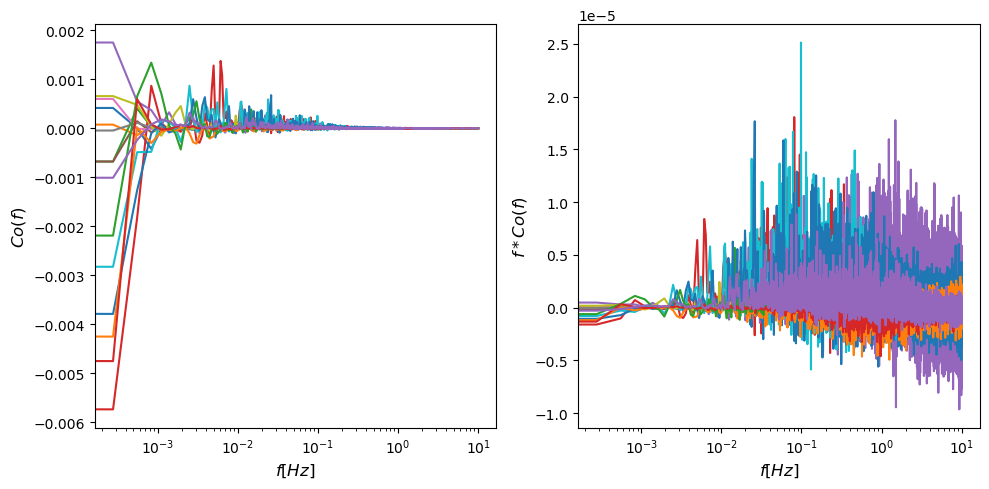

In [20]:
#Compute the energy spectra

f = FourierCoSpectra()



#### An example on how to represent the co-spectrum:

![](CoSpectra3.png)

<div class="alert alert-block alert-danger">
<b>Problem:</b> In this case the fluxes (and hence the cospectra) are not necessarily positive. This means that one have to be cautious when plotting the results using a logarithmic scale in the vertical direction. The alternative is to leave the y-axis in linear scale, as represented above.
The challenge is that it is hard to visualize the details. The solution is to split the vertical axis in two subsegments. First plot the positive side, then the negative side, and then patch together the subplots. 
</div>

## Wavelet Analysis

(**Disclaimer:** *more detailed information about wavelet analysis can be found in the article of Marie Farge in Annual Reviews of Fluid Mechanics, "Wavelet Transforms and their applications to Turbuelnce", 1992.*)

* Wavelet analysis allows one to unfold a signal, or a field, into both space and scale.


* Wavelet decomposition uses analyzing functions, called wavelets, which are localized in space (see Figure 1).

![](Wavelet2.png)
**Figure 1** -- *Examples of Wavelet functions.*



* The scale decomposition is obtained by dilating or contracting the chosen analyzing wavelet before convolving it with the signal.


* Wavelet analysis or synthesis can be performed locally on the signal, as opposed to the Fourier transform which is inherently nonlocal due to the space-filling nature of the trigonometric functions.


* The continuous wavelet transform of a function or a distribution $f(x)$ is the $L^2$-inner product between $f$ and the wavelet family $\psi_{lx'\theta}$, which gives the wavelet coefficients:

\begin{equation}
\tilde{f}(l,x',\theta) = \langle \psi_{lx'\theta}|f\rangle = \int_R f(x)\psi^*_{lx'\theta}(x)\,d^nx,
\end{equation}


* Equivalent as what we did for the Fourier transform, one can define the space-scale energy density as:

\begin{equation}
E(l,x) = \frac{|\tilde{f}(l,x)|^2}{l^n} \label{eq:51}
\end{equation}

<div class="alert alert-block alert-info">
<b>Example:</b> How does one compute the Energy Spectrum using Wavelets in practice? 
</div>

### Steps to Compute Energy Spectrum using Wavelets

1. Take the signal you are interested to analyze (e.g. $u(t)$)


2. Remove NaNs from the signals (e.g. add zeros, interpolate, etc).


3. Transform your signals, each to a new signal with length power of 2 (e.g. $2^M$).


4. Remove the "mean" of the signal you will decompose. (Challenge: What is the right mean period?)


5. Decide Wavelet form to be used for the decomposition.


6. Compute the continuous wavelet transform.


7. Compute the scales & associated frequencies


8. Plot


* (Note: In comparison to the Fourier Transform, we do not need to Window the signal prior to transforming it.)


In [8]:
def Wavelet_Trasnform():

    # We begin by importing the Libraries that we will need to 

    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import xarray as xr


    #Loading the Data to be analyzed: ------------------------------------------------

    # Include the path to where you have locally stored the data file.
    file_path = "/Users/mcalaf/Documents/Utah/Courses/Summer_school_Norway_2022/Lecture1/"

    os.chdir(file_path)
    #----------------------------------------------------------------------------------

    #Preparing the Data to be analyzed: ------------------------------------------------

    # Next, we load the information in the data file onto the variable Data. This variable is a dataarray, 
    # with 2 dimensions (.dims) and 4 coordinates (.coords, u,v,w,T)

    Data = xr.open_dataarray("SonicData.nc")

    # To simplify the analysis, we will focus for now only on the streamwise velocity, u.
    u = Data.data[:,0]

    # At the same time, and for the sake of simplifying the analysis, we Rensure there are no NaNs in the Signal.
    # If we encounter any, we set them to zero. Note, that when you analyze your data you might/could decide using 
    # more advnaced methods to fill in the gaps. Clearly, depending on what you do, it might affect the outcome
    # of your analysis.

    testNan = np.isnan(u)
    ind = np.where(testNan == True)
    u[ind] = 0

    Number_of_Nans = np.size(ind) #Determines how many NaNs have been found.
    # Next, we define a couple parameters related to the signal.print(f"The total number of NaNs found is of {Number_of_Nans} points")

    #Make the Signal a power of 2.
    M = np.floor(np.log2(len(u))) #Maximum Power of 2 within the length of the signal measure at 20Hz.
    u_short = u[0:int(2**M)]

    Signal = u_short - np.mean(u_short)

    #----------------------------------------------------------------------------------

    #Computing Wavelet Transform: -----------------------------------------------------

    import pywt

    #Web page with information about the python wavelet library:
    #https://pywavelets.readthedocs.io/en/latest/ref/cwt.html  

    wavlist = pywt.wavelist(kind='continuous')
    #print(wavlist)

    dt = 1/20
    scales = np.int64(2**(np.arange(1,M+1)))

    #print(scales[0],scales[-1])
    #print(freq[0],freq[-1])

    [coefs, freq] = pywt.cwt(Signal, scales,'cmor1.5-1.0',dt, method='fft')

    Energy = (np.abs(coefs))**2
    Spectra = np.mean(Energy,1)


    time = np.arange(0,2**(M))*(dt/3600)

    #bottom = 0

    #----------------------------------------------------------------------------------

    #Plotting Wavelet Transform: -----------------------------------------------------

    plt.figure()
    plt.imshow(np.log(Energy), aspect='auto',origin='lower',
           extent = [0, ((2**M)/20/3600), freq[0], freq[-1]],vmin=-10,vmax=15)
    plt.colorbar()
    plt.ylabel('f[Hz]')
    plt.xlabel('t (hr)')
    plt.title('Wavelet Decomposition')
    plt.show()


    fig, axs=plt.subplots(1,2,figsize=(10,5))

    axs[0].loglog(freq,Spectra,'-')
    axs[0].set_xlabel('$f [Hz]$')
    axs[0].set_ylabel('$E(f)$')

    axs[1].loglog(freq,freq*Spectra,'-')
    axs[1].set_xlabel('$f [Hz]$')
    axs[1].set_ylabel('$f*E(f)$')

    plt.tight_layout()
    plt.show()

    #----------------------------------------------------------------------------------


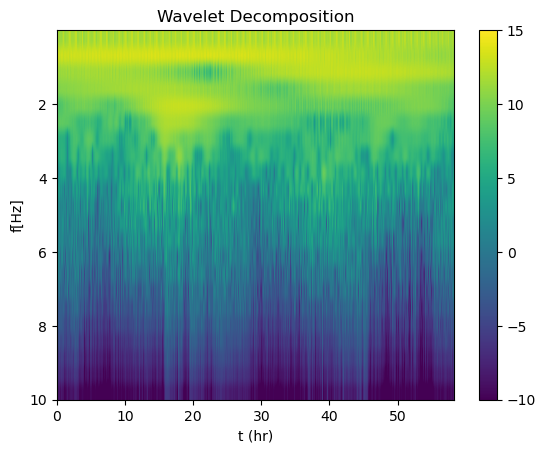

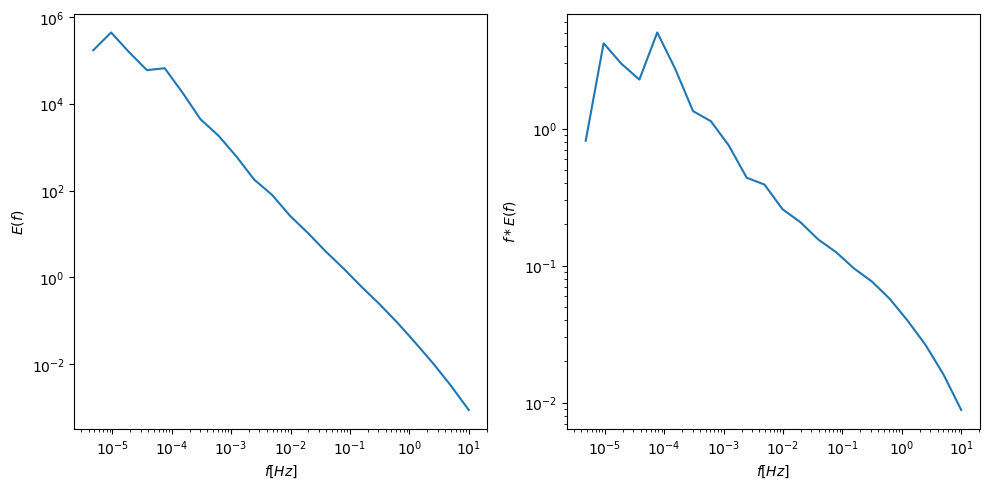

In [9]:
# Let's compute the Wavelet trasnform

Wavelet_Trasnform()

## Multi-resolution Decomposition (MRD)

(**Disclaimer:** *The theory in this section is based on the paper of Vickers and Mahrt, 2003, in the Journal of Atmospheric and Oceanic Technology. A more detailed explanation of the Multiresolution flux decomposition technique can be found in the original paper of Howell and Mahrt, 1997 in Boundary-Layer Meteorology.*)


* Multiresolution analysis applied to time series decomposes the record into averages on different time scales and represents the simplest possible orthogonal decomposition. 


* Multiresolution (MR) spectra yields information on the scale dependence of the variance as do Fourier spectra, but unlike Fourier spectra, MR spectra satisfy Reynold's averaging at all scales and do not assume periodicity (Howell and Mahrt 1997).


* Multiresolution spectra can be interpreted in terms of using simple unweighted moving averages.


* Analysis of turbulence measurements require the researcher to choose a timescale $t$ (or a length scale for space measurements) to define the fluctuations. The calculated flux includes all scales of motion from the smallest resolved by the instrumentation up to the specified averaging timescale $t$, and therefore, the calculated flux depends on the choice of $t$. 

### Multiresolution decomposition

* Consider a time series $w_i$ consisting of $i= 1, 2, ... 2^M$ points. 


* Multiresolution decomposition partitions the record into simple averages on different scales (segments) of width $1, 2, 4, . . . 2^M$ consecutive data points. 


* The lowest order mode (largest scale) is the simple average over the record, which is then removed (Fig. 1a). 


* The next mode consists of the means of the two half records (Fig. 1b), which are then removed. 


* The third mode consists of the averages of the four subrecords, and so forth. 


* This procedure can be thought of as a highpass filter that, with each application, removes increasingly shorter averaging timescale fluctuations.

![](figureMRD.png)
**Figure 1**- *Steps in multiresolution decomposition*

For a given scale $m$, the averaging segments of width $2^m$ points are sequenced as $n= 1, 2, ... 2^{M-m}$, where $n$ identifies the position of the segment within the series. The average for the $n$-th segment at scale $m$ is given by

\begin{equation}
\overline{w}_n(m)= \frac{1}{2^m}\sum_{i=I}^{J}wr_i(m) \label{eq.1}
\end{equation}

where $wr_i(m)$ is the residual series with segment averages for windows of width $> 2^m$ points removed. The $wr_i(M)$ is the original series $w_i$. In Eq. (\ref{eq.1}), $I= (n-1)2^m + 1$ and $J = n\,2^m$. In this notation, the lowest order mode (largest averaging timescale) corresponds to $m = M$, while the highest order mode (shortest averaging timescale) corresponds to $m= 0$. 



The MR spectra are the second moment about the mean of the segment averages, given by

\begin{equation}
D_w(m+1) = \frac{1}{2^{M-m}}\sum_{n=1}^{2^{M-m}} \overline{w}_n^2(m),
\end{equation}

since the record mean of the segment averages is zero. This process is schematically represented in Figure 2. 

![](figureMRD2.png)
**Figure 2**- *(a) Multiresolution averaging window basis set. (b) Schematic of the partitioning of the record into $2^{M-m}$ averaging windows.*


* Fourier decomposition imposes periodic basis functions, and therefore an explicit relationship between Fourier spectra and MR spectra, or between Fourier spectra and Reynold's averaging, does not exist. 


* The correspondence between our MR spectra notation and Fourier spectra is

\begin{equation}
D_w(m) \sim f S_w(f) = k F_w(k)
\end{equation}

* The MR spectra has units of variance. 


* The frequencies and wavenumbers associated with the MR spectra averaging timescales are $f =(\delta t 2^m)^{-1}, \,\,\,\,\, m = 1,M$ and $k = f/U$, respectively, where $\delta t$ is the time interval (s) between data points and $U$ is mean wind speed ($m/s$). 


* Normalized MR spectra are given by

\begin{equation}
G_w(n)= \frac{D_w(n)}{\sum D_w}
\end{equation}

such that $G_w(n)$ is the fraction of the vertical velocity variance associated with normalized frequency $n$, where $n=fz/U$.

### Multiresolution Cospectrum

To calculate MR cospectra for two time series $w$ and $f$, the same averaging and reduction procedures are applied as discussed above for MR spectra except that there are two time series and the cospectra are given by

\begin{equation}
D_{w\phi}(m+1) = \frac{1}{2^{M-m}}\sum_{n=1}^{2^{M-m}} \overline{w}_n(m)\overline{\phi}_n(m).
\end{equation}

The sum of $D_{w\phi}(m)$ over averaging scales $m=1,P$ is precisely equal to the average eddy correlation flux calculated using an averaging scale of $2^P$ points,

\begin{equation}
\sum_{m=1}^P D_{w\phi}(m) = [(w-\overline{w}^p)(\phi-\overline{\phi}^p)],
\end{equation}

where the overbar refers to a $2^P$-point local averaging scale and the square brackets denote the record mean. The record length ($2^M$ points) determines the time period over which the estimates of the flux are averaged. When $P=M$ there is a single timescale and the relationship between the MR cospectra and the eddy correlation flux simplifies to 

\begin{equation}
\sum_{m=1}^P D_{w\phi}(m) = [(w-[w])(\phi-[\phi])].
\end{equation}

The right-hand side of equation \ref{eq5} is the traditional Reynolds flux.





<div class="alert alert-block alert-info">
<b>Example:</b> How does one compute the Energy Spectrum using Multi-resolution decomposition in practice? 
</div>

In [26]:
def MRD_decomp():
    
    # We begin by importing the Libraries that we will need to 

    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import xarray as xr


    #Loading the Data to be analyzed: ------------------------------------------------

    # Include the path to where you have locally stored the data file.
    file_path = "/Users/mcalaf/Documents/Utah/Courses/Summer_school_Norway_2022/Lecture1/"

    os.chdir(file_path)
    
    # Next, we load the information in the data file onto the variable Data. This variable is a dataarray, 
    # with 2 dimensions (.dims) and 4 coordinates (.coords, u,v,w,T)

    Data = xr.open_dataarray("SonicData.nc")

    # To simplify the analysis, we will focus for now only on the streamwise velocity, u.
    u = Data.data[:,0]

    # At the same time, and for the sake of simplifying the analysis, we Rensure there are no NaNs in the Signal.
    # If we encounter any, we set them to zero. Note, that when you analyze your data you might/could decide using 
    # more advnaced methods to fill in the gaps. Clearly, depending on what you do, it might affect the outcome
    # of your analysis.

    testNan = np.isnan(u)
    ind = np.where(testNan == True)
    u[ind] = 0

    Number_of_Nans = np.size(ind) #Determines how many NaNs have been found.
    # Next, we define a couple parameters related to the signal.print(f"The total number of NaNs found is of {Number_of_Nans} points")

    #Make the Signal a power of 2.
    M = np.int64(np.floor(np.log2(len(u)))) #Maximum Power of 2 within the length of the signal measure at 20Hz.
    u_short = u[0:int(2**M)]

    #-----------------------------------------------------------------------------------
    var1 = u_short
    var2 = u_short
    
    a = np.array(var1)
    b = np.array(var2)
    
    D = np.zeros(M+1)
    Mx = 0
    for ims in range(0,M-Mx+1):
        ms = M-ims  # Scale
        l = 2**ms    # Number of points (width) of the averaging segments "nw" at a given scale "m".
        nw = np.int64((2**M)/l)  # Number of segments, each with "l" number of points.
        
        sumab = 0
        
        
        for i in range(1,nw+1):  #Loop through the different averaging segments "nw" 
            k = (i-1)*l
            za = a[k]
            zb = b[k]
        
            for j in range(k+1,k+l):  #Loop within the datapoints inside one specific [i] segment (ot of the total "nw").
                za = za + a[j]  #Cumulative sum of subsegment "i" in time series "a"
                zb = zb + b[j]  #Cumulative sum of subsegment "i" in time series "b"
            
            za = za/l
            zb = zb/l
            sumab = sumab + (za*zb)
                
            for j in range(k,i*l): #Subtract the mean from the time series to form the residual to be reused in next iteration. 
                tmpa = a[j] - za
                tmpb = b[j] - zb
                a[j] = tmpa
                b[j] = tmpb
            
        
        if nw>1: #Computing the MR spectra at a given scale[m]. For scale ms = M is the largest scale.
            D[ms] = (sumab/nw)

    #-----------------------------------------------------------------------------------
    # Comparing the Variance with the sum of the Spectra Power:

    var = np.var(u_short)
    MRDvar = np.sum(D)
    print(var,MRDvar)  

    
    #%% Graphical Representation of the MRD energy spectr in semilog and loglog form.

    import matplotlib
    matplotlib.rcParams['text.usetex'] = False
    import matplotlib.patches as mpatches


    dt = 1/20  #Frequency of measurements.
    t = 2**(np.arange(Mx,M+1))*dt
    f = 1/t

    E = D

    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.semilogx(f[1:-1],E[1:-1],color='black',linewidth=8,alpha=0.4)
    ax2.loglog(f[1:-1],E[1:-1],color='black',linewidth=8,alpha=0.4)

    ax1.set(ylabel='$f\,S_{TKE}(f)$'); ax2.set(ylabel='$f\,S_{TKE}(f)$')
    ax1.set(xlabel='$f\,\,[Hz]$'); ax2.set(xlabel='$f\,\,[Hz]$')

    ax2.set_ylim((1e-5, 1e0))

    ylim_ax1 = 1.2; ax1.set_ylim(0,ylim_ax1)
    ymin = 1e-3
    ylim_ax2 = 2; ax2.set_ylim(ymin,ylim_ax2)

    day = 1/(24*3600)
    twelveHr = 1/(12*3600)
    sixhour = 1/(6*3600)
    halfhour = 1/(1800)
    fivemin = 1/(5*60)

    ax2.plot([day, day], [ymin, ylim_ax2],linestyle=':',color='k',linewidth=1)
    ax2.plot([twelveHr, twelveHr], [ymin, ylim_ax2],linestyle=':',color='k',linewidth=1)
    ax2.plot([sixhour, sixhour], [ymin, ylim_ax2],linestyle=':',color='k',linewidth=1)
    ax2.plot([halfhour, halfhour], [ymin, ylim_ax2],linestyle=':',color='k',linewidth=1)
    ax2.plot([fivemin, fivemin], [ymin, ylim_ax2],linestyle=':',color='k',linewidth=1)

    angle = 90
    ycorner = 1
    l1 = np.array((1e-5, 1e-2))
    th1 = ax2.text(l1[0], l1[1], '$T_p = 1 \,day$', fontsize=10,
               rotation=angle, rotation_mode='anchor')
    l2 = np.array((2e-5, 1e-2))
    th2 = ax2.text(l2[0], l2[1], '$T_p = 12\,h $', fontsize=10,
               rotation=angle, rotation_mode='anchor')
    l3 = np.array((8e-5, 1e-2))
    th2 = ax2.text(l3[0], l3[1], '$T_p = 6\,h $', fontsize=10,
               rotation=angle, rotation_mode='anchor')
    l4 = np.array((4e-4, 1e-2))
    th2 = ax2.text(l4[0], l4[1], '$T_p = 30\,min$', fontsize=10,
               rotation=angle, rotation_mode='anchor')
    l5 = np.array((2e-3, 1e-2))
    th2 = ax2.text(l5[0], l5[1], '$T_p = 5\,min$', fontsize=10,
               rotation=angle, rotation_mode='anchor')

    plt.tight_layout()
    plt.show()
    
    

5.086065628655815 5.086065628655877


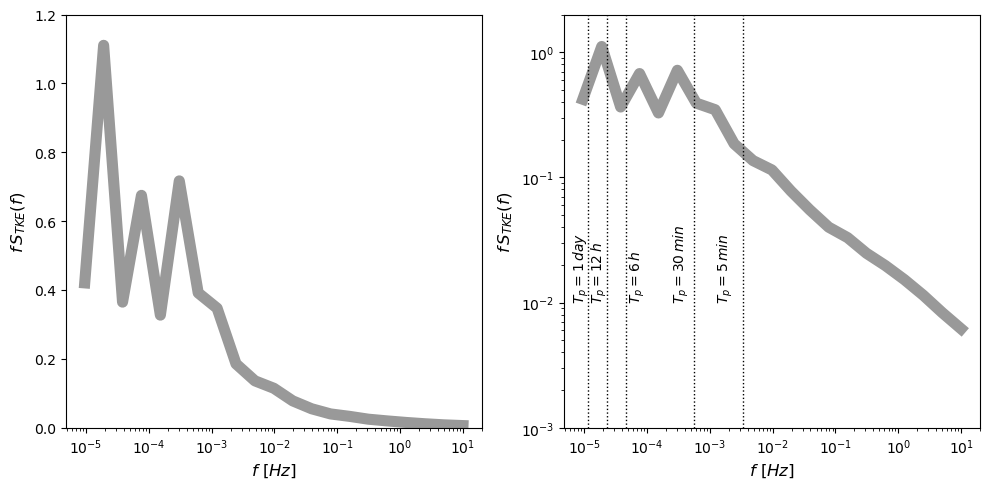

In [27]:
# Let's compute the MRD decomposition of the same IPAQS dataset

MRD_decomp()

## Proper Orthogonal Decomposition

* The problem was originally posed for the study of turbulence by John Lumley.


* Suppose we have a random velocity field, $u_i(\cdot)$, where '$\cdot$' represents $\vec{x},t$ or some subset of them. 


* We seek to find a deterministic vector field, say $\phi_i(\cdot)$, which has the maximum projection on our random vector field, $u_i$, in a mean square sense. 


* In other words, we would like to find a whole new deterministic field represented by $\phi_i(\cdot)$ for which $\langle|u_i(\cdot),\phi_i(\cdot)^*|^2\rangle$ is maximized.



If we think of both $u_i$ and $\phi_i$ as functions belonging to Hilbert space, then this inner product can be written as:

\begin{equation}
(u_i(\cdot),\phi_i(\cdot)^*) = \int\int\int_v u_i(\cdot)\phi_i(\cdot)^* \,d(\cdot)
\end{equation}

where the integral is over the entire domain defined by the physical extent of the
turbulent field.


* By the calculus of variations one can show that the appropriate choice of $\phi_i(\cdot)$ to maximize its projection onto the velocity field is the solution to the following integral equation:


\begin{equation}
\int_{region} R_{ij}(\cdot,\cdot')\phi_j(\cdot')\,d(\cdot) = \lambda \phi(\cdot) \label{eq:10.3}
\end{equation}

where $R_{ij}(\cdot,\cdot')$ is the *two point* correlation function given by,

\begin{equation}
R_{ij}(\cdot,\cdot') \equiv \langle u_i(\cdot)u_j(\cdot')\rangle
\end{equation}

and

\begin{equation}
\lambda = \langle |\alpha^2|\rangle
\end{equation}

where $\alpha$ is defined by

\begin{equation}
\alpha = \int_{region} u_i(\cdot)\phi_i(\cdot) \, d(\cdot)
\end{equation}

* Thus, finding the very best choice of our special deterministic function, $\phi_i(\cdot)$, to represent the random velocity field, $u_i(\cdot)$, has reduced to finding a solution to an integral equation for $\phi(\cdot)$ in which the kernel is given by the two-point correlation function, $R_{ij}(\cdot,\cdot')$. 




* Once we have all the $\phi(\cdot)$ solutions, we can reconstruct the original velocity field from them as:

\begin{equation}
u_i(\cdot) = \sum_{n=1}^\infty a_n\phi_i^{(n)}(\cdot) \label{eq:10.9}
\end{equation}


* The random coefficients $a_n$ are functions of the variables not used in the integral, and must be determined by projection back onto the velocity field; i.e.

\begin{equation}
a_n=\int_{region} u_i(\cdot)\phi_i^{*(n)}(\cdot)\,d(\cdot)
\end{equation}


* One can show using the fact that the $\phi^{(n)}(\cdot)$ are orthonormal that the random coefficients are uncorrelated,

\begin{equation}
\lambda_n = \langle a_na_m\rangle \delta_{nm}
\end{equation}




* Since we can reconstruct the velocity, of course we can reconstruct the two point Reynolds stress tensor, $R_{ij}(\cdot,\cdot')$. The result after self-multiplication and averaging of equation \ref{eq:10.9} is:

\begin{equation}
R_{ij}(\cdot,\cdot') = \sum_{n=1}^{\infty} \lambda_n \phi_i^{(n)}(\cdot)\phi_j^{(n)}(\cdot')
\end{equation}


* The eigenvalues are ordered (meaning that the lowest order eigenvalue is bigger that the next, and so on); i.e, $\lambda_1 > \lambda_2 > \lambda_3 ...$. 


* Thus *the representation is optimal (or 'proper') in the sense that the fewest number of terms is required to capture the energy.* This is VERY important, and it is possibly the only reason any one cares at all about the POD. 


* It is truly the most efficient way to break-down a field of finite total energy into pieces, at least from the perspective of the energy. 

Don't be too bothered by the fact that we really don't know in general what our particular orthogonal functions are, and may not even be able to find them analytically. But we do know how to find them numerically and empirically - if we have enough information about the two point velocity correlation.


* A finite subset of these functions can be used to produce a finite number of equations for analysis. This is accomplished by using them in a Galerkin projection on the governing equations (in our case the instantaneous Navier-Stokes equations). 


* By truncating after a specified number of modes, the infinitely dimensional governing equations are reduced to a finite set.


<div class="alert alert-block alert-info">
<b>Example:</b> How does one compute a Proper Orthogonal Decomposition of the turbulence signal, and compute the Energy Spectrum in practice? 
</div>

(View the additional script for the details of the POD analysis)